In [43]:
import matplotlib.pyplot as plt
import numpy as np
import ase
from ase.io import *
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# keep this setting always at the top
VERY_SMALL_SIZE = 12 # Added a new variable for smaller size
SMALL_SIZE = 16
MEDIUM_SIZE = 22
BIGGER_SIZE = 20
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams.update({
    'font.family': 'DejaVu Sans'
})

In [44]:
import pandas as pd

In [46]:
def plot_table(data, x_column, value_columns, title, filename, xlabel, ylabel="Value", xticks=None,
               multiple_lines=True, legend_labels=None):
    """
    Generic function to plot data from tables
    """
    plt.figure(figsize=(10, 6))

    # If we're plotting multiple values on the same graph
    if multiple_lines:
        for i, col in enumerate(value_columns):
            label = legend_labels[i] if legend_labels else col
            plt.plot(data[x_column], data[col], marker='o', linestyle='-',
                     linewidth=2, markersize=8, label=label, color=colors[i])
        plt.legend() # Removed fontsize
    else:
        plt.plot(data[x_column], data[value_columns[0]], marker='o', linestyle='-',
                 linewidth=2, markersize=8, color=colors[0])

    # Set x-ticks explicitly if provided
    if xticks is not None:
        plt.xticks(xticks)

    plt.title(title, fontweight='bold') # Removed fontsize
    plt.xlabel(xlabel) # Removed fontsize
    plt.ylabel(ylabel) # Removed fontsize
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f'plots/{filename}.pdf', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

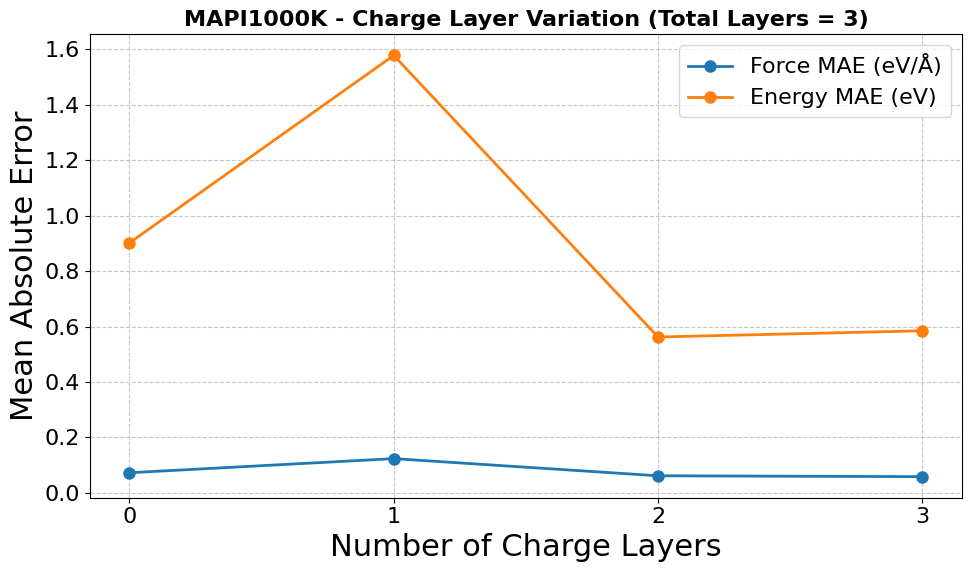

In [48]:
import os

# Create the 'plots' directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')

# ------------------------------------------------------------------------------
# 1. MAPI1000K Dataset
# ------------------------------------------------------------------------------

# 1.1 Charge Layer Variation (Total Layers = 3)
data_1_1 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3],
    'f_mae': [0.072782, 0.123662, 0.061835, 0.058681],
    'e_mae': [0.901294, 1.577349, 0.562185, 0.584568],
    'e/N_mae': [0.009388, 0.016431, 0.005856, 0.006089]
})

plot_table(
    data_1_1, 'n_charge', ['f_mae', 'e_mae'],
    'MAPI1000K - Charge Layer Variation (Total Layers = 3)',
    'mapi_1_1_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 4),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)


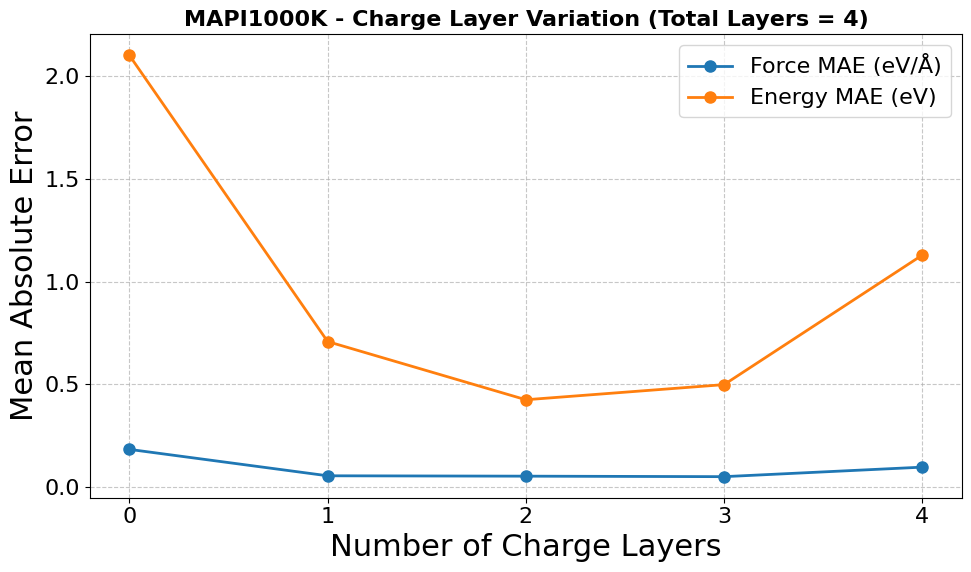

In [49]:

# 1.2 Charge Layer Variation (Total Layers = 4)
data_1_2 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3, 4],
    'model': ['NEquIP', 'NEquIP-LR', 'NEquIP-LR', 'NEquIP-LR', 'NEquIP-LR'],
    'f_mae': [0.184149, 0.055685, 0.053880, 0.051466, 0.097778],
    'e_mae': [2.100765, 0.708633, 0.425607, 0.499241, 1.129627],
    'e/N_mae': [0.021883, 0.007382, 0.004233, 0.005200, 0.011767]
})

plot_table(
    data_1_2, 'n_charge', ['f_mae', 'e_mae'],
    'MAPI1000K - Charge Layer Variation (Total Layers = 4)',
    'mapi_1_2_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 5),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)

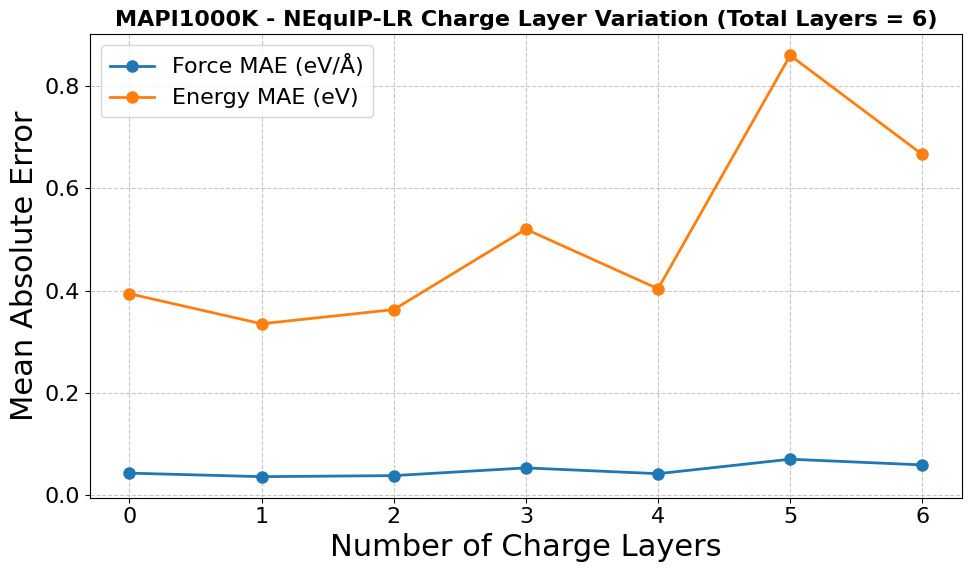

In [50]:

# 1.2.1 NEquIP-LR (Charge Encoding) - Total Layers = 6
data_1_2_1 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3, 4, 5, 6],
    'f_mae': [0.043252, 0.036346, 0.038373, 0.053466, 0.042153, 0.070449, 0.059281],
    'e_mae': [0.393750, 0.335005, 0.362729, 0.519740, 0.403392, 0.859333, 0.665777],
    'e/N_mae': [0.004102, 0.003490, 0.003778, 0.005414, 0.004202, 0.008951, 0.006935]
})

plot_table(
    data_1_2_1, 'n_charge', ['f_mae', 'e_mae'],
    'MAPI1000K - NEquIP-LR Charge Layer Variation (Total Layers = 6)',
    'mapi_1_2_1_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 7),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)



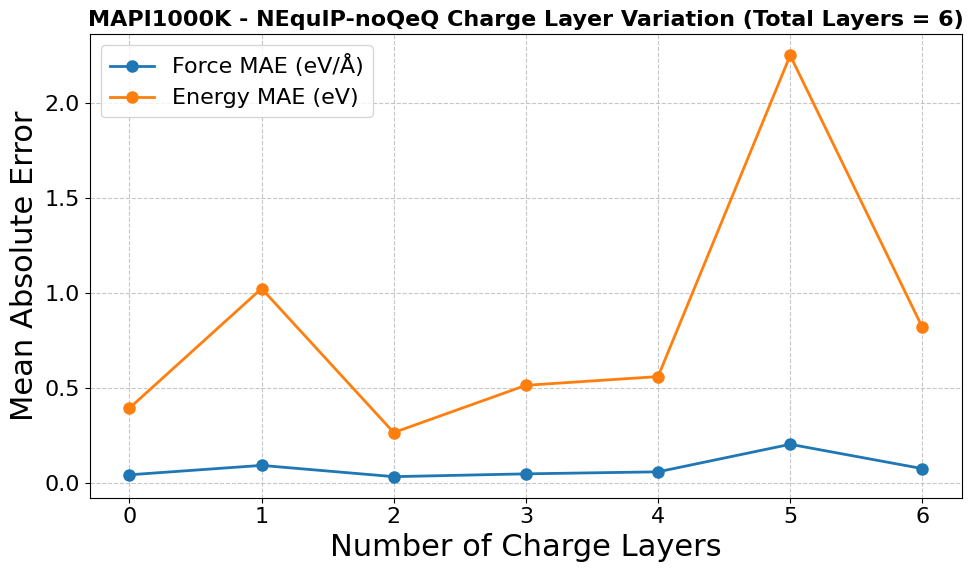

In [51]:

# 1.2.2 NEquIP-noQeQ Branch
data_1_2_2 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3, 4, 5, 6],
    'f_mae': [0.043252, 0.092711, 0.033452, 0.048241, 0.058869, 0.203602, 0.075748],
    'e_mae': [0.393750, 1.022670, 0.265367, 0.513812, 0.559674, 2.248575, 0.818591]
})

plot_table(
    data_1_2_2, 'n_charge', ['f_mae', 'e_mae'],
    'MAPI1000K - NEquIP-noQeQ Charge Layer Variation (Total Layers = 6)',
    'mapi_1_2_2_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 7),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)



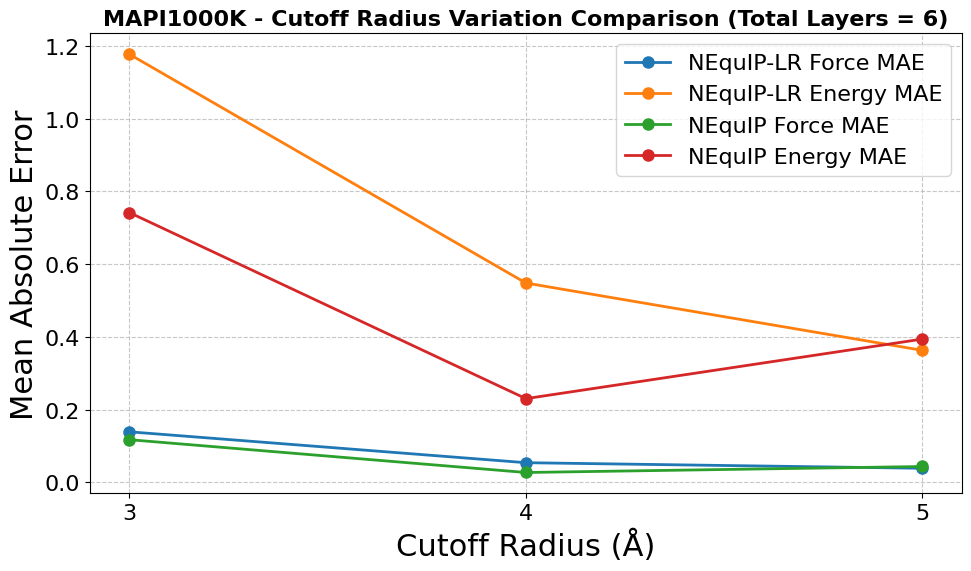

In [54]:
# 1.3 Cutoff Radius (rmax) Variation - NEquIP-LR
data_1_3_1 = pd.DataFrame({
    'rmax': [3.0, 4.0, 5.0],
    'f_mae': [0.138675, 0.053708, 0.038373],
    'e_mae': [1.177262, 0.547961, 0.362729],
    'e/N_mae': [0.012263, np.nan, np.nan]  # Missing values
})

# 1.3 Cutoff Radius (rmax) Variation - NEquIP
data_1_3_2 = pd.DataFrame({
    'rmax': [3.0, 4.0, 5.0],
    'f_mae': [0.116975, 0.026748, 0.043252],
    'e_mae': [0.741719, 0.229922, 0.393750],
    'e/N_mae': [0.007726, 0.002395, 0.004102]
})

# Combine data for cutoff radius comparison
data_1_3_1_renamed = data_1_3_1.rename(columns={'f_mae': 'f_mae_nequip_lr', 'e_mae': 'e_mae_nequip_lr'})
data_1_3_2_renamed = data_1_3_2.rename(columns={'f_mae': 'f_mae_nequip', 'e_mae': 'e_mae_nequip'})

comparison_data_rmax = pd.merge(data_1_3_1_renamed[['rmax', 'f_mae_nequip_lr', 'e_mae_nequip_lr']],
                              data_1_3_2_renamed[['rmax', 'f_mae_nequip', 'e_mae_nequip']],
                              on='rmax')

# Combined plot for cutoff radius comparison using plot_table
plot_table(
    comparison_data_rmax,
    'rmax',
    ['f_mae_nequip_lr', 'e_mae_nequip_lr', 'f_mae_nequip', 'e_mae_nequip'],
    'MAPI1000K - Cutoff Radius Variation Comparison (Total Layers = 6)',
    'mapi_1_3_rmax_comparison',
    'Cutoff Radius (Å)',
    'Mean Absolute Error',
    xticks=[3.0, 4.0, 5.0],
    legend_labels=['NEquIP-LR Force MAE', 'NEquIP-LR Energy MAE', 'NEquIP Force MAE', 'NEquIP Energy MAE']
)

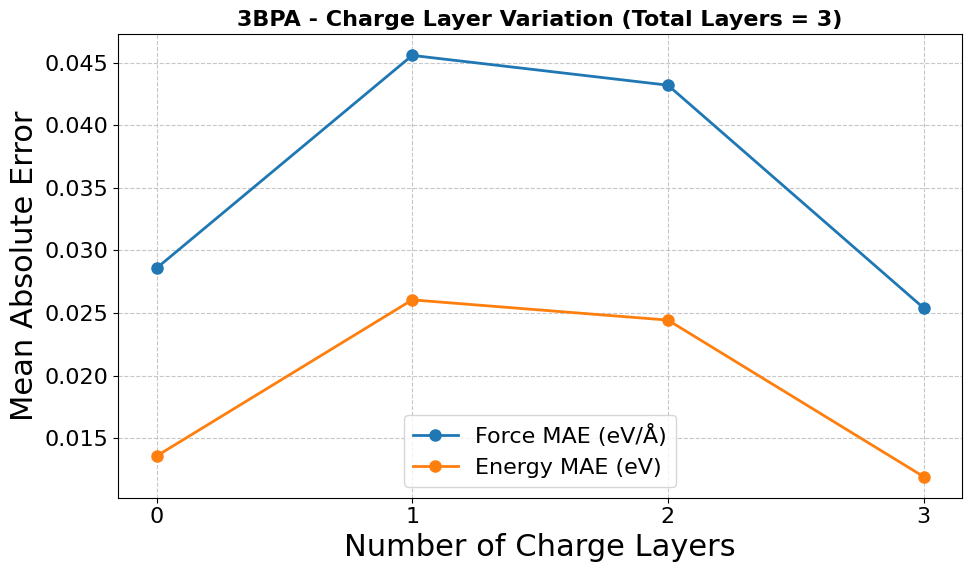

In [55]:
# ------------------------------------------------------------------------------
# 2. 3BPA Dataset
# ------------------------------------------------------------------------------

# 2.1 Charge Layer Variation (Total Layers = 3)
data_2_1 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3],
    'model': ['NEquIP-LR', 'NEquIP-LR', 'NEquIP-LR', 'NEquIP-LR'],
    'f_mae': [0.028580, 0.045568, 0.043190, 0.025407],
    'e_mae': [0.013588, 0.026055, 0.024439, 0.011943],
    'e/N_mae': [0.000503, 0.000965, 0.000905, 0.000442]
})

plot_table(
    data_2_1, 'n_charge', ['f_mae', 'e_mae'],
    '3BPA - Charge Layer Variation (Total Layers = 3)',
    '3bpa_2_1_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 4),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)


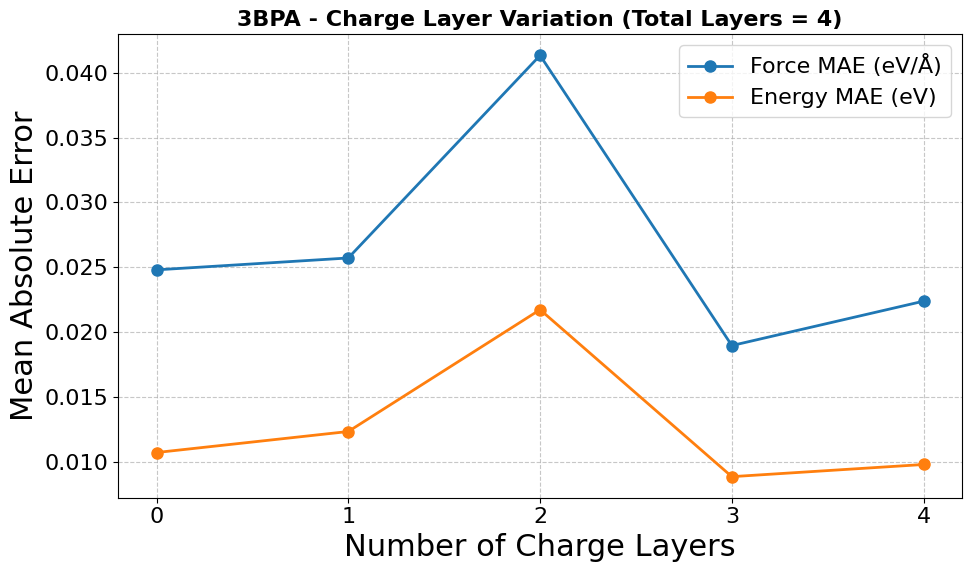

In [56]:


# 2.2 Charge Layer Variation (Total Layers = 4)
data_2_2 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3, 4],
    'model': ['NEquIP-LR', 'NEquIP-LR', 'NEquIP-LR', 'NEquIP-LR', 'NEquIP-LR'],
    'f_mae': [0.024790, 0.025707, 0.041336, 0.018950, 0.022375],
    'e_mae': [0.010697, 0.012319, 0.021718, 0.008835, 0.009774],
    'e/N_mae': [0.000396, 0.000456, 0.000804, np.nan, 0.000362]
})

plot_table(
    data_2_2, 'n_charge', ['f_mae', 'e_mae'],
    '3BPA - Charge Layer Variation (Total Layers = 4)',
    '3bpa_2_2_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 5),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)


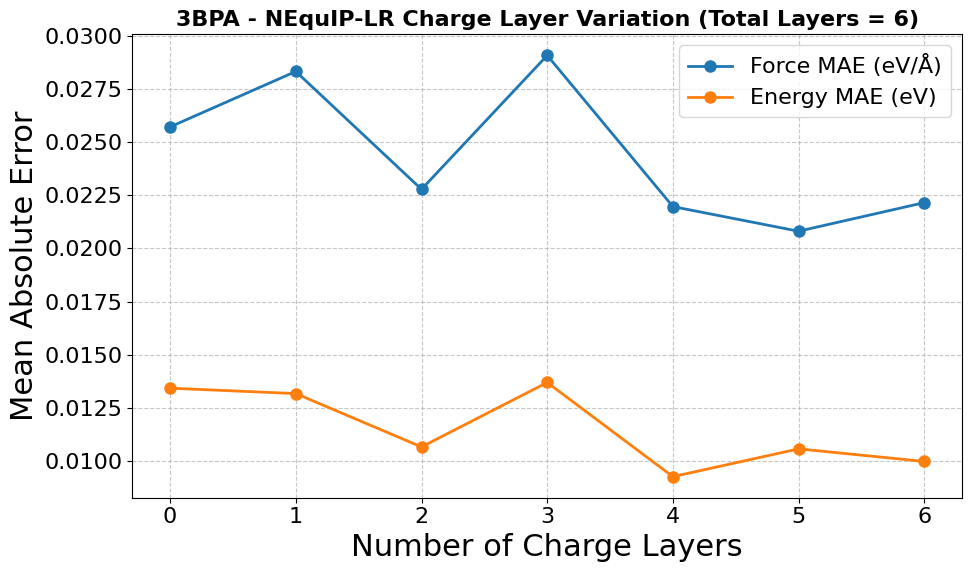

In [57]:

# 2.3.1 NEquIP-LR (Charge Encoding) - Total Layers = 6
data_2_3_1 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3, 4, 5, 6],
    'f_mae': [0.025718, 0.028327, 0.022782, 0.029082, 0.021968, 0.020810, 0.022155],
    'e_mae': [0.013425, 0.013170, 0.010661, 0.013693, 0.009262, 0.010570, 0.009977],
    'e/N_mae': [0.000497, 0.000488, 0.000395, 0.000507, 0.000343, 0.000391, 0.000370]
})

plot_table(
    data_2_3_1, 'n_charge', ['f_mae', 'e_mae'],
    '3BPA - NEquIP-LR Charge Layer Variation (Total Layers = 6)',
    '3bpa_2_3_1_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 7),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)

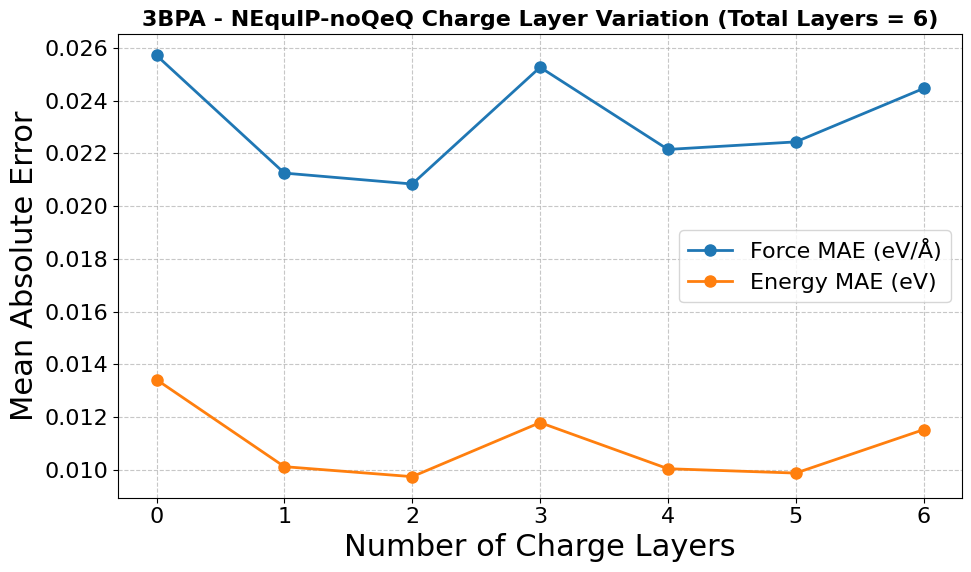

In [58]:

# 2.3.2 NEquIP-noQeQ Branch
data_2_3_2 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3, 4, 5, 6],
    'f_mae': [0.025718, 0.021256, 0.020842, 0.025268, 0.022153, 0.022439, 0.024466],
    'e_mae': [0.013425, 0.010126, 0.009747, 0.011797, 0.010048, 0.009883, 0.011530]
})

plot_table(
    data_2_3_2, 'n_charge', ['f_mae', 'e_mae'],
    '3BPA - NEquIP-noQeQ Charge Layer Variation (Total Layers = 6)',
    '3bpa_2_3_2_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 7),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)

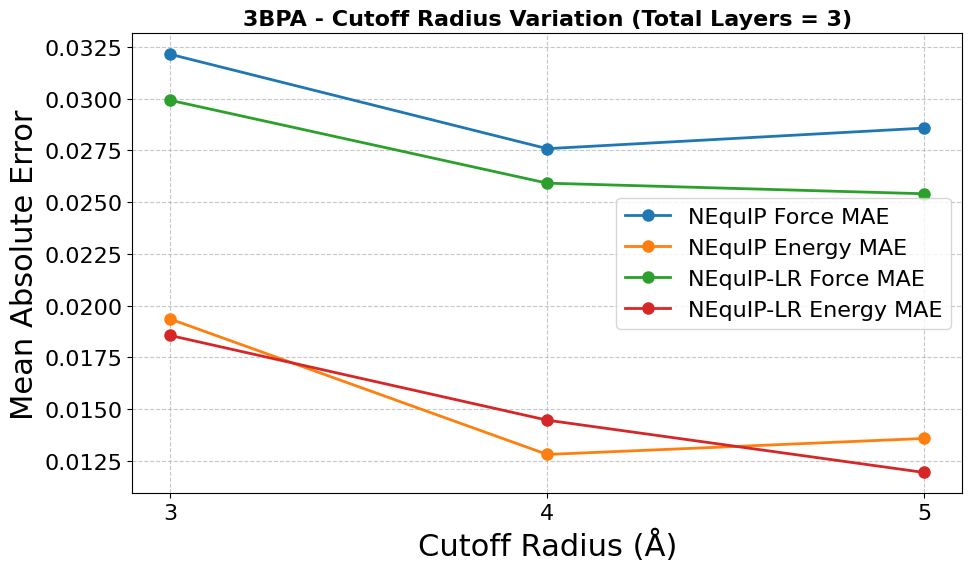

In [59]:
# 2.4 Cutoff Radius Variations for different layers
# 2.4.1 Total Layers = 3
data_2_4_1_nequip = pd.DataFrame({
    'rmax': [3, 4, 5],
    'f_mae': [0.032146, 0.027585, 0.028580],
    'e_mae': [0.019357, 0.012814, 0.013588]
})

data_2_4_1_nequip_lr = pd.DataFrame({
    'rmax': [3, 4, 5],
    'f_mae': [0.029923, 0.025919, 0.025407],
    'e_mae': [0.018563, 0.014470, 0.011943]
})

# Combine data for comparison
comparison_data_2_4_1 = pd.merge(
    data_2_4_1_nequip.rename(columns={'f_mae': 'nequip_f_mae', 'e_mae': 'nequip_e_mae'}),
    data_2_4_1_nequip_lr.rename(columns={'f_mae': 'nequip_lr_f_mae', 'e_mae': 'nequip_lr_e_mae'}),
    on='rmax'
)

# Plot for Total Layers = 3, comparing NEquIP and NEquIP-LR using plot_table
plot_table(
    comparison_data_2_4_1,
    'rmax',
    ['nequip_f_mae', 'nequip_e_mae', 'nequip_lr_f_mae', 'nequip_lr_e_mae'],
    '3BPA - Cutoff Radius Variation (Total Layers = 3)',
    '3bpa_2_4_1_rmax_comparison',
    'Cutoff Radius (Å)',
    'Mean Absolute Error',
    xticks=[3, 4, 5],
    legend_labels=['NEquIP Force MAE', 'NEquIP Energy MAE', 'NEquIP-LR Force MAE', 'NEquIP-LR Energy MAE']
)

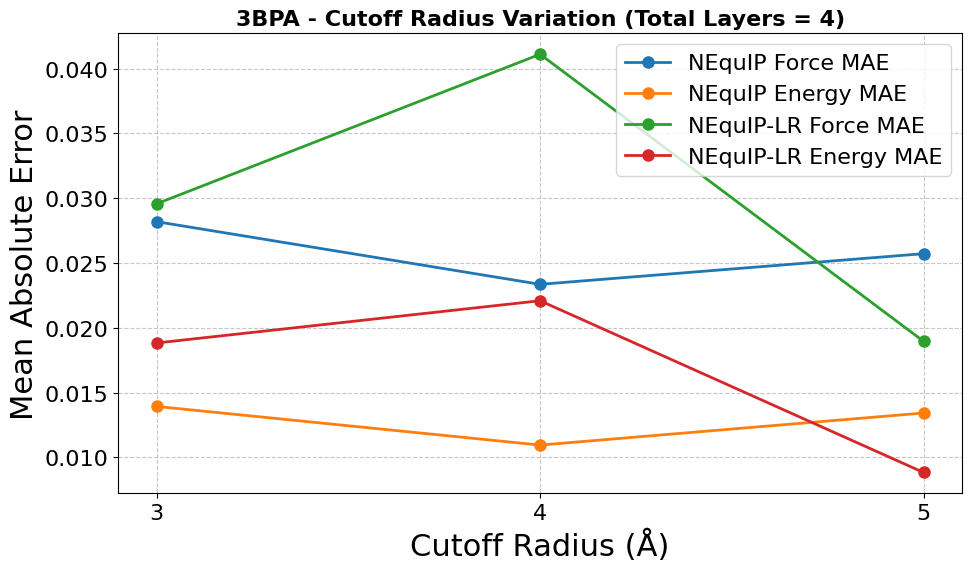

In [62]:
# 2.4.2 Total Layers = 4
data_2_4_2_nequip_lr = pd.DataFrame({
    'rmax': [3, 4, 5],
    'f_mae': [0.029563, 0.041104, 0.018950],
    'e_mae': [0.018828, 0.022087, 0.008835],
    'e/N_mae': [0.000697, 0.000818, np.nan]
})

data_2_4_2_nequip = pd.DataFrame({
    'rmax': [3, 4, 5],
    'f_mae': [0.028188, 0.023353, 0.025718],
    'e_mae': [0.017228, 0.010950, 0.013425]
})

# Combine data for comparison
comparison_data_2_4_2 = pd.merge(
    data_2_4_2_nequip.rename(columns={'f_mae': 'nequip_f_mae', 'e_mae': 'nequip_e_mae'}),
    data_2_4_2_nequip_lr.rename(columns={'f_mae': 'nequip_lr_f_mae', 'e_mae': 'nequip_lr_e_mae'}),
    on='rmax'
)

# Plot for Total Layers = 4, comparing NEquIP and NEquIP-LR using plot_table
plot_table(
    comparison_data_2_4_2,
    'rmax',
    ['nequip_f_mae', 'nequip_e_mae', 'nequip_lr_f_mae', 'nequip_lr_e_mae'],
    '3BPA - Cutoff Radius Variation (Total Layers = 4)',
    '3bpa_2_4_2_rmax_comparison',
    'Cutoff Radius (Å)',
    'Mean Absolute Error',
    xticks=[3, 4, 5],
    legend_labels=['NEquIP Force MAE', 'NEquIP Energy MAE', 'NEquIP-LR Force MAE', 'NEquIP-LR Energy MAE']
)

In [63]:
# 2.4.3 Total Layers = 6
data_2_4_3_nequip_lr = pd.DataFrame({
    'rmax': [3, 4, 5],
    'f_mae': [0.028833, 0.027763, 0.022782],
    'e_mae': [0.016317, 0.013127, 0.010661],
    'e/N_mae': [0.000604, 0.000486, 0.000395]
})

data_2_4_3_nequip = pd.DataFrame({
    'rmax': [3, 4, 5],
    'f_mae': [0.025323, 0.024370, 0.025718],
    'e_mae': [0.013933, 0.011776, 0.013425],
    'e/N_mae': [0.000516, 0.000436, 0.000497]
})


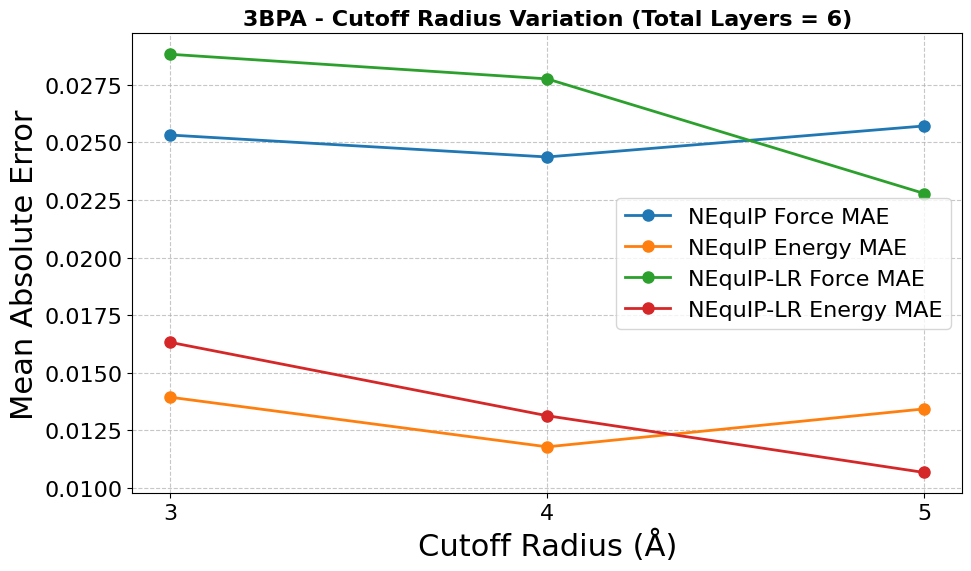

In [64]:
# 2.4.3 Total Layers = 6
data_2_4_3_nequip_lr = pd.DataFrame({
    'rmax': [3, 4, 5],
    'f_mae': [0.028833, 0.027763, 0.022782],
    'e_mae': [0.016317, 0.013127, 0.010661],
    'e/N_mae': [0.000604, 0.000486, 0.000395]
})

data_2_4_3_nequip = pd.DataFrame({
    'rmax': [3, 4, 5],
    'f_mae': [0.025323, 0.024370, 0.025718],
    'e_mae': [0.013933, 0.011776, 0.013425],
    'e/N_mae': [0.000516, 0.000436, 0.000497]
})

# Combine data for comparison
comparison_data_2_4_3 = pd.merge(
    data_2_4_3_nequip.rename(columns={'f_mae': 'nequip_f_mae', 'e_mae': 'nequip_e_mae'}),
    data_2_4_3_nequip_lr.rename(columns={'f_mae': 'nequip_lr_f_mae', 'e_mae': 'nequip_lr_e_mae'}),
    on='rmax'
)

# Plot for Total Layers = 6, comparing NEquIP and NEquIP-LR using plot_table
plot_table(
    comparison_data_2_4_3,
    'rmax',
    ['nequip_f_mae', 'nequip_e_mae', 'nequip_lr_f_mae', 'nequip_lr_e_mae'],
    '3BPA - Cutoff Radius Variation (Total Layers = 6)',
    '3bpa_2_4_3_rmax_comparison',
    'Cutoff Radius (Å)',
    'Mean Absolute Error',
    xticks=[3, 4, 5],
    legend_labels=['NEquIP Force MAE', 'NEquIP Energy MAE', 'NEquIP-LR Force MAE', 'NEquIP-LR Energy MAE']
)

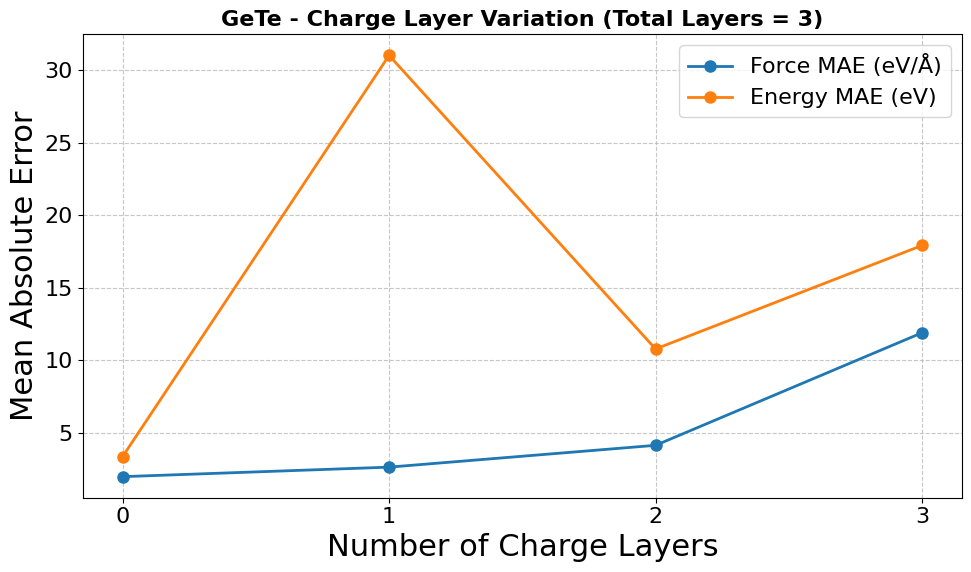

In [65]:

# ------------------------------------------------------------------------------
# 3. GeTe Dataset
# ------------------------------------------------------------------------------

# 3.1 Charge Layer Variation (Total Layers = 3)
data_3_1 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3],
    'f_mae': [1.991741, 2.647799, 4.151660, 11.910707],
    'e_mae': [3.379050, 31.028854, 10.792540, 17.928699]
})

plot_table(
    data_3_1, 'n_charge', ['f_mae', 'e_mae'],
    'GeTe - Charge Layer Variation (Total Layers = 3)',
    'gete_3_1_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 4),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)


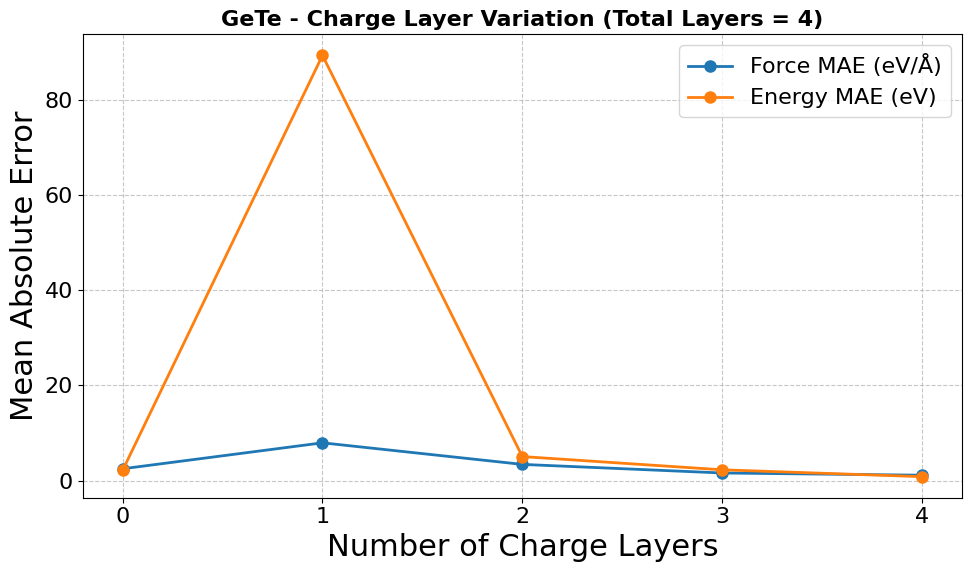

In [66]:

# 3.2 Charge Layer Variation (Total Layers = 4)
data_3_2 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3, 4],
    'f_mae': [2.496615, 7.945761, 3.415764, 1.611934, 1.148685],
    'e_mae': [2.167891, 89.264259, 5.060729, 2.276979, 0.842432]
})

plot_table(
    data_3_2, 'n_charge', ['f_mae', 'e_mae'],
    'GeTe - Charge Layer Variation (Total Layers = 4)',
    'gete_3_2_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 5),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)


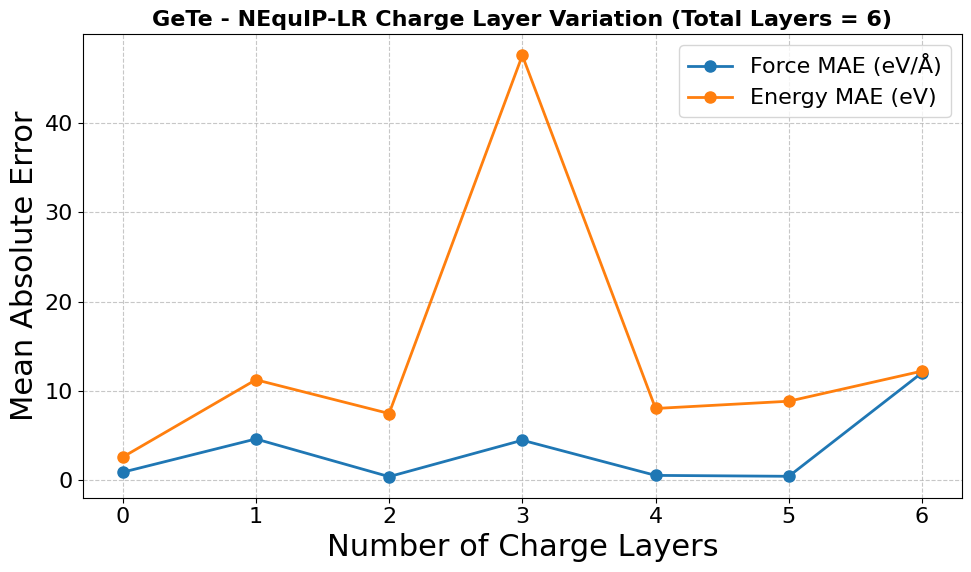

In [67]:

# 3.3.1 NEquIP-LR (Charge Encoding) - Total Layers = 6
data_3_3_1 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3, 4, 5, 6],
    'f_mae': [0.874339, 4.601954, 0.377638, 4.460473, 0.519346, 0.418282, 12.024601],
    'e_mae': [2.563542, 11.234857, 7.452135, 47.577240, 8.017422, 8.829323, 12.204453]
})

plot_table(
    data_3_3_1, 'n_charge', ['f_mae', 'e_mae'],
    'GeTe - NEquIP-LR Charge Layer Variation (Total Layers = 6)',
    'gete_3_3_1_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 7),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)


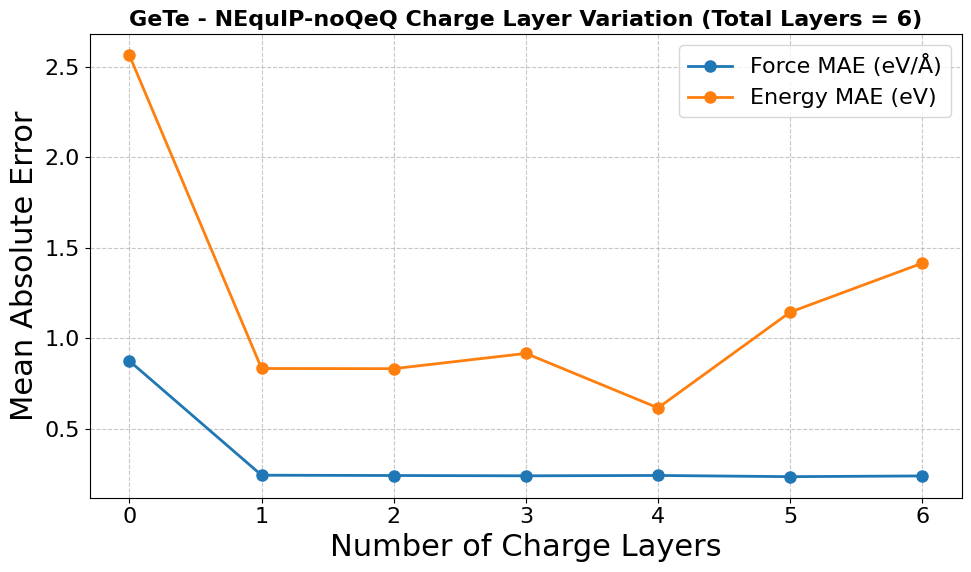

All plots have been generated and saved to the 'plots' directory.


In [68]:
# 3.3.2 NEquIP-noQeQ Branch
data_3_3_2 = pd.DataFrame({
    'n_charge': [0, 1, 2, 3, 4, 5, 6],
    'f_mae': [0.874339, 0.242904, 0.241251, 0.239561, 0.241532, 0.234879, 0.238885],
    'e_mae': [2.563542, 0.832826, 0.831849, 0.916237, 0.615117, 1.144414, 1.415169]
})

plot_table(
    data_3_3_2, 'n_charge', ['f_mae', 'e_mae'],
    'GeTe - NEquIP-noQeQ Charge Layer Variation (Total Layers = 6)',
    'gete_3_3_2_force_energy',
    'Number of Charge Layers',
    'Mean Absolute Error',
    xticks=range(0, 7),
    legend_labels=['Force MAE (eV/Å)', 'Energy MAE (eV)']
)

print("All plots have been generated and saved to the 'plots' directory.")

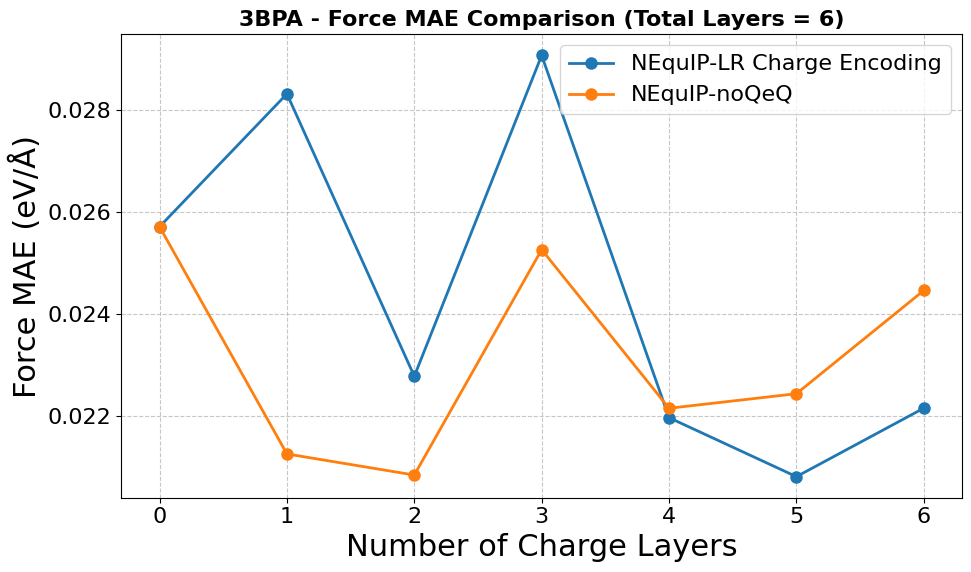

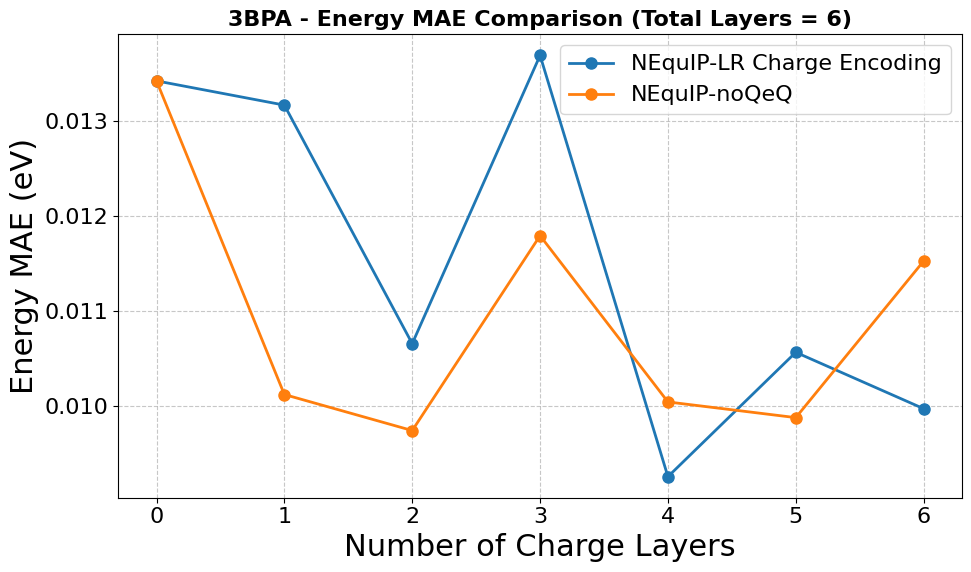

In [69]:
data_2_3_1_renamed = data_2_3_1.rename(columns={'f_mae': 'f_mae_charge_encoding', 'e_mae': 'e_mae_charge_encoding'})
data_2_3_2_renamed = data_2_3_2.rename(columns={'f_mae': 'f_mae_noqeq', 'e_mae': 'e_mae_noqeq'})

comparison_data_3bpa = pd.merge(data_2_3_1_renamed[['n_charge', 'f_mae_charge_encoding', 'e_mae_charge_encoding']],
                                data_2_3_2_renamed[['n_charge', 'f_mae_noqeq', 'e_mae_noqeq']],
                                on='n_charge')

# Plot Force MAE comparison for 3BPA
plot_table(
    comparison_data_3bpa,
    'n_charge',
    ['f_mae_charge_encoding', 'f_mae_noqeq'],
    '3BPA - Force MAE Comparison (Total Layers = 6)',
    '3bpa_force_mae_comparison',
    'Number of Charge Layers',
    'Force MAE (eV/Å)',
    xticks=range(0, 7),
    legend_labels=['NEquIP-LR Charge Encoding', 'NEquIP-noQeQ']
)

# Plot Energy MAE comparison for 3BPA
plot_table(
    comparison_data_3bpa,
    'n_charge',
    ['e_mae_charge_encoding', 'e_mae_noqeq'],
    '3BPA - Energy MAE Comparison (Total Layers = 6)',
    '3bpa_energy_mae_comparison',
    'Number of Charge Layers',
    'Energy MAE (eV)',
    xticks=range(0, 7),
    legend_labels=['NEquIP-LR Charge Encoding', 'NEquIP-noQeQ']
)

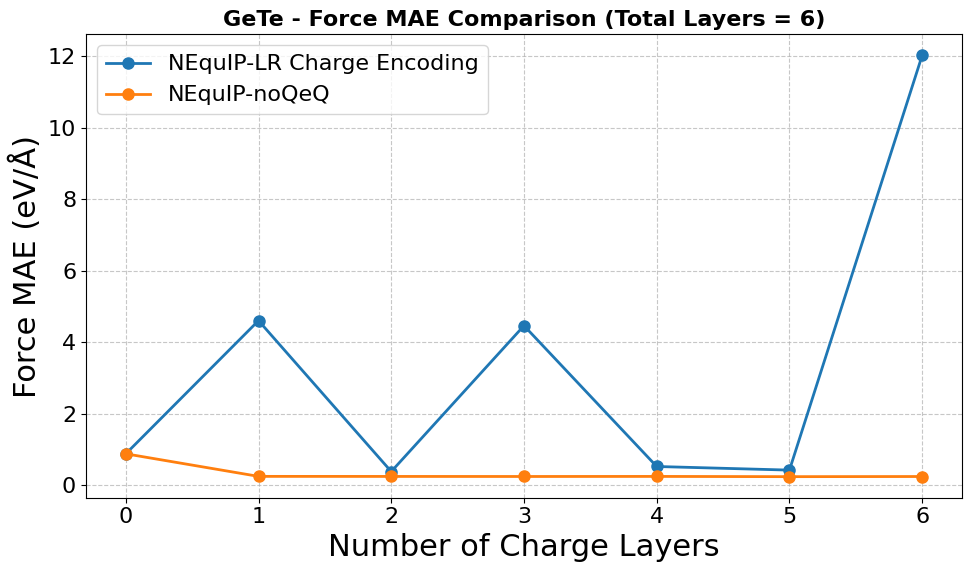

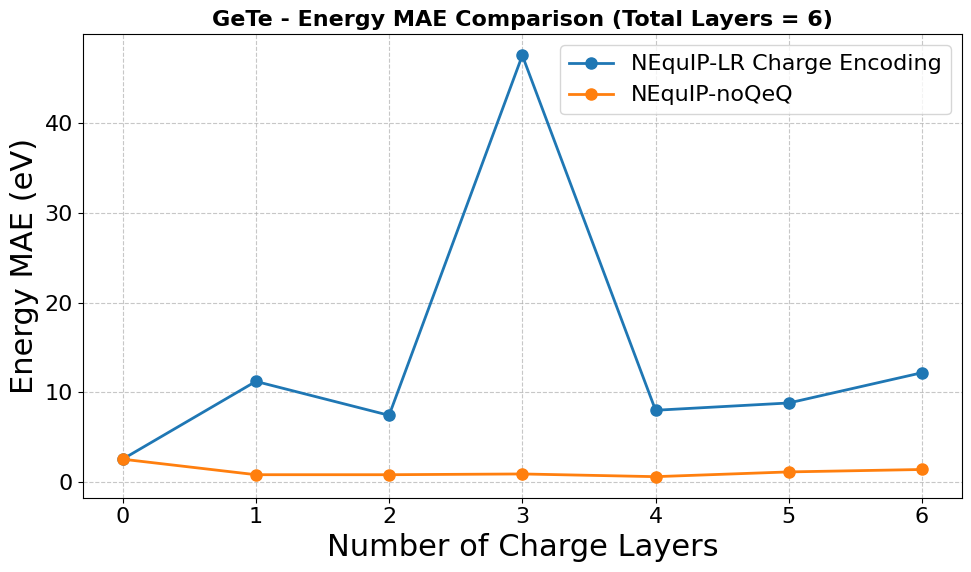

In [70]:
data_3_3_1_renamed = data_3_3_1.rename(columns={'f_mae': 'f_mae_charge_encoding', 'e_mae': 'e_mae_charge_encoding'})
data_3_3_2_renamed = data_3_3_2.rename(columns={'f_mae': 'f_mae_noqeq', 'e_mae': 'e_mae_noqeq'})

# Merge the dataframes on 'n_charge'
comparison_data_gete = pd.merge(data_3_3_1_renamed[['n_charge', 'f_mae_charge_encoding', 'e_mae_charge_encoding']],
                                data_3_3_2_renamed[['n_charge', 'f_mae_noqeq', 'e_mae_noqeq']],
                                on='n_charge')

# Plot Force MAE comparison for GeTe
plot_table(
    comparison_data_gete,
    'n_charge',
    ['f_mae_charge_encoding', 'f_mae_noqeq'],
    'GeTe - Force MAE Comparison (Total Layers = 6)',
    'gete_force_mae_comparison',
    'Number of Charge Layers',
    'Force MAE (eV/Å)',
    xticks=range(0, 7),
    legend_labels=['NEquIP-LR Charge Encoding', 'NEquIP-noQeQ']
)

# Plot Energy MAE comparison for GeTe
plot_table(
    comparison_data_gete,
    'n_charge',
    ['e_mae_charge_encoding', 'e_mae_noqeq'],
    'GeTe - Energy MAE Comparison (Total Layers = 6)',
    'gete_energy_mae_comparison',
    'Number of Charge Layers',
    'Energy MAE (eV)',
    xticks=range(0, 7),
    legend_labels=['NEquIP-LR Charge Encoding', 'NEquIP-noQeQ']
)

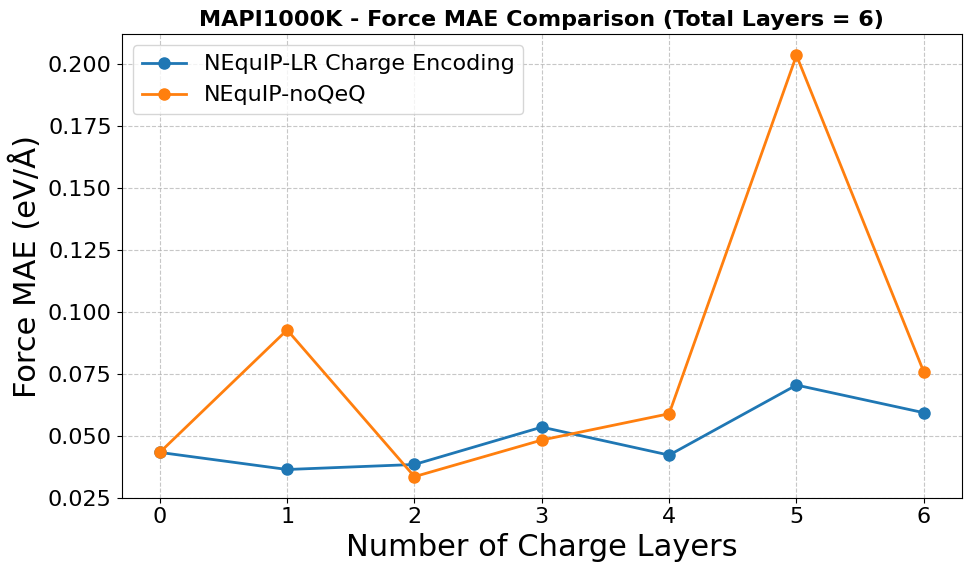

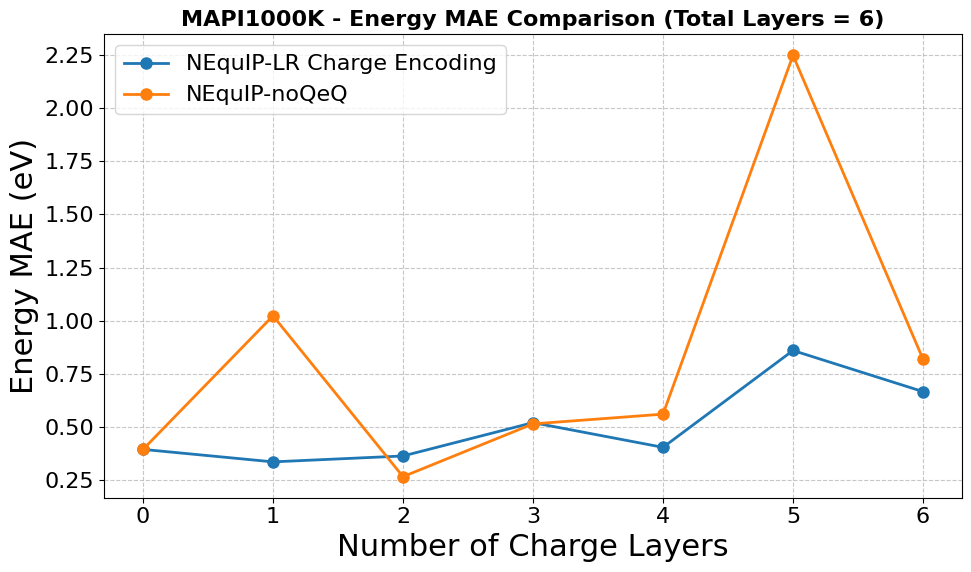

In [71]:
data_1_2_1_renamed = data_1_2_1.rename(columns={'f_mae': 'f_mae_charge_encoding', 'e_mae': 'e_mae_charge_encoding'})
data_1_2_2_renamed = data_1_2_2.rename(columns={'f_mae': 'f_mae_noqeq', 'e_mae': 'e_mae_noqeq'})

comparison_data_mapi = pd.merge(data_1_2_1_renamed[['n_charge', 'f_mae_charge_encoding', 'e_mae_charge_encoding']],
                                data_1_2_2_renamed[['n_charge', 'f_mae_noqeq', 'e_mae_noqeq']],
                                on='n_charge')

# Plot Force MAE comparison for MAPI1000K
plot_table(
    comparison_data_mapi,
    'n_charge',
    ['f_mae_charge_encoding', 'f_mae_noqeq'],
    'MAPI1000K - Force MAE Comparison (Total Layers = 6)',
    'mapi_force_mae_comparison',
    'Number of Charge Layers',
    'Force MAE (eV/Å)',
    xticks=range(0, 7),
    legend_labels=['NEquIP-LR Charge Encoding', 'NEquIP-noQeQ']
)

# Plot Energy MAE comparison for MAPI1000K
plot_table(
    comparison_data_mapi,
    'n_charge',
    ['e_mae_charge_encoding', 'e_mae_noqeq'],
    'MAPI1000K - Energy MAE Comparison (Total Layers = 6)',
    'mapi_energy_mae_comparison',
    'Number of Charge Layers',
    'Energy MAE (eV)',
    xticks=range(0, 7),
    legend_labels=['NEquIP-LR Charge Encoding', 'NEquIP-noQeQ']
)